In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(
    './data',
    train=True,
    download=True,
    transform=transform
) 

test_set = datasets.MNIST(
    './data',
    train=False,
    download=True,
    transform=transform
)

# Split training into train/val

train_size = 50000
val_size = 10000
train_set, val_set = random_split(full_train, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=64,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=64,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=64,
    shuffle=False
)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

# WHY validation set?
# - Train set:  model learns FROM this
# - Val set:    you tune hyperparameters using this (learning rate, epochs, etc.)
# - Test set:   final unbiased evaluation — touch it ONCE at the very end
# Using test set for tuning = cheating (data leakage)


Train: 50000 | Val: 10000 | Test: 10000


In [9]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)

# Training   
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() 
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Prevents exploding gradients — clips gradient norm to max 1.0
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return total_loss / len(loader), 100 * correct / total  # later on train_loss and train_acc

# Evaluation 
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader :
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return total_loss / len(loader), 100 * correct / total   # later on val_loss and val_acc

# Setup 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),  lr = 0.001)

# Learing rate scheduler - so if the validation loss stops improving for 3 epochs, i.e, patience = 3, then it will reduce the learning rate by 0.5 

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode = 'min',
    factor = 0.5,
    patience = 3,
)

# Early Stopping - so if the validation loss stops improving for 5 epochs, i.e, patience = 5, then it will stop training

best_val_loss = float('inf')
patience       = 5
patience_count = 0
best_model_state = None
        
# History tracking

history = {
    'train_loss': [], 'val_loss': [], 
    'train_acc': [], 'val_acc': [] 
}

print("Training on : ", device)

for epoch in range(30):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_count   = 0
        print(f" New best model saved (val_loss: {best_val_loss:.4f})")
    else:
        patience_count += 1
        if patience_count > patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Restore best model
model.load_state_dict(best_model_state)
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\n🏆 Final Test Accuracy: {test_acc:.2f}%")

Training on :  cuda
Epoch  1 | Train Loss: 0.3350 Acc: 89.8% | Val Loss: 0.1494 Acc: 95.4%
 New best model saved (val_loss: 0.1494)
Epoch  2 | Train Loss: 0.1590 Acc: 95.2% | Val Loss: 0.1016 Acc: 96.7%
 New best model saved (val_loss: 0.1016)
Epoch  3 | Train Loss: 0.1276 Acc: 96.3% | Val Loss: 0.1058 Acc: 96.9%
Epoch  4 | Train Loss: 0.1073 Acc: 96.8% | Val Loss: 0.0824 Acc: 97.6%
 New best model saved (val_loss: 0.0824)
Epoch  5 | Train Loss: 0.0960 Acc: 97.1% | Val Loss: 0.0817 Acc: 97.6%
 New best model saved (val_loss: 0.0817)
Epoch  6 | Train Loss: 0.0871 Acc: 97.3% | Val Loss: 0.0836 Acc: 97.5%
Epoch  7 | Train Loss: 0.0787 Acc: 97.6% | Val Loss: 0.0830 Acc: 97.5%
Epoch  8 | Train Loss: 0.0724 Acc: 97.8% | Val Loss: 0.0851 Acc: 97.8%
Epoch  9 | Train Loss: 0.0715 Acc: 97.7% | Val Loss: 0.0850 Acc: 97.8%
Epoch 10 | Train Loss: 0.0488 Acc: 98.5% | Val Loss: 0.0691 Acc: 98.1%
 New best model saved (val_loss: 0.0691)
Epoch 11 | Train Loss: 0.0414 Acc: 98.7% | Val Loss: 0.0740 Acc: 

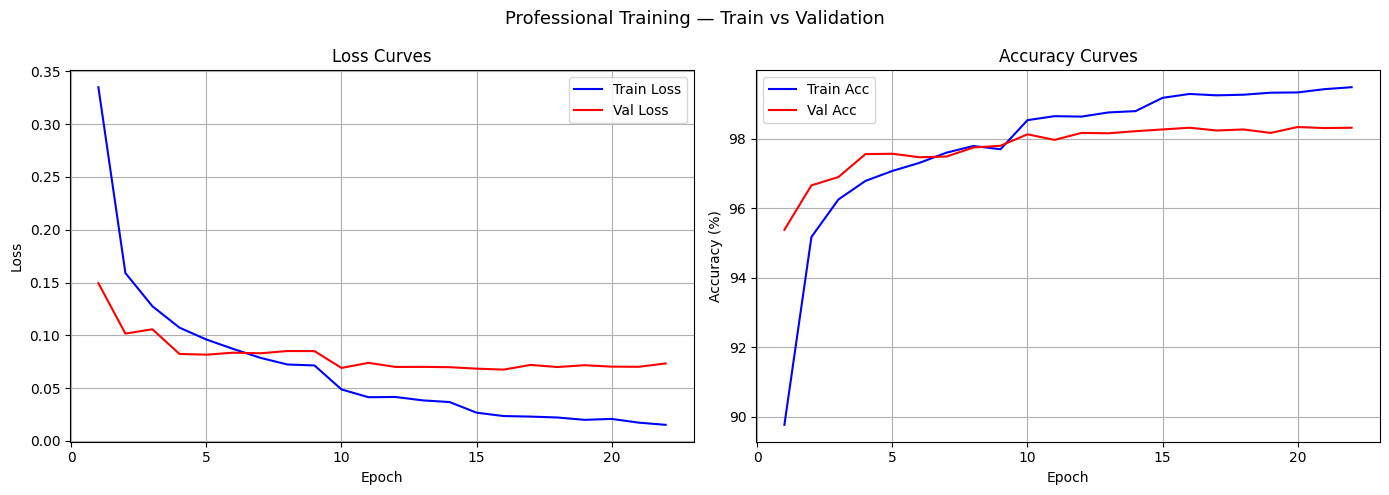

In [10]:
import matplotlib.pyplot as plt

epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, history['train_loss'], 'b-', label='Train Loss')
ax1.plot(x, history['val_loss'],   'r-', label='Val Loss')
ax1.set_title("Loss Curves")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(x, history['train_acc'], 'b-', label='Train Acc')
ax2.plot(x, history['val_acc'],   'r-', label='Val Acc')
ax2.set_title("Accuracy Curves")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.suptitle("Professional Training — Train vs Validation", fontsize=13)
plt.tight_layout()
plt.show()

# KEY THING TO LOOK FOR:
# If train acc >> val acc → overfitting (model memorized training data)
# If both plateau → good convergence
# If val loss starts going UP while train loss goes DOWN → overfitting beginning
